# 04 — SHAP Explainability: PPI Distress Classifier
**Infrastructure Project Risk Predictor — Random Forest**

This notebook produces all SHAP outputs for the deployed Random Forest model.

Sections:
- **A** — Leakage audit (hard gate: stops if any forbidden feature appears in top 20)
- **B** — Global importance: bar plot and beeswarm (top 20)
- **C** — Category-level signal: where does predictive power actually come from?
- **D** — Hypothesis validation (H1 sector, H2 CAM-complexity, H3 WGI governance)
- **E** — Three waterfall plots (high-risk / low-risk / boundary)
- **F** — Dependence plots for top 3 features

All figures saved to `notebooks/figures/04_*.png`.
SHAP values cached at `models/shap_values_train.npy`.


## Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys, os, json, pickle, importlib.util
from pathlib import Path
from IPython.display import Image, display

ROOT = Path(os.getcwd())
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
NOTEBOOKS_DIR = ROOT / "notebooks"
sys.path.insert(0, str(NOTEBOOKS_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

spec = importlib.util.spec_from_file_location("shap_script", NOTEBOOKS_DIR / "shap_script.py")
ss = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ss)

# Load data + model
train = pd.read_parquet(ROOT / "data" / "processed" / "features_train.parquet")
with open(ROOT / "models" / "feature_cols.json") as f:
    feature_cols = json.load(f)
with open(ROOT / "models" / "best_model_uncalibrated.pkl", "rb") as f:
    rf = pickle.load(f)

X_train = train[feature_cols].values.astype("float32")
y_train = train["target"].values.astype("int32")
proba   = rf.predict_proba(X_train)[:, 1]

print(f"Train: {X_train.shape}, positives: {y_train.sum()} ({y_train.mean()*100:.1f}%)")


Train: (8435, 87), positives: 608 (7.2%)


In [2]:
# Load cached SHAP values (or compute if missing)
shap_cache = ROOT / "models" / "shap_values_train.npy"
explainer  = shap.TreeExplainer(rf)

if shap_cache.exists():
    shap_vals = np.load(shap_cache)
    print(f"Loaded cached SHAP values: {shap_vals.shape}")
else:
    print("Computing SHAP values (~2 min)...")
    sv_raw = explainer.shap_values(X_train)
    if isinstance(sv_raw, list):
        shap_vals = sv_raw[1]
    elif sv_raw.ndim == 3:
        shap_vals = sv_raw[:, :, 1]
    else:
        shap_vals = sv_raw
    np.save(shap_cache, shap_vals)
    print(f"Computed and cached: {shap_vals.shape}")

base_val = ss._get_base_value(explainer)
print(f"SHAP base value (expected model output): {base_val:.4f}")


Loaded cached SHAP values: (8435, 87)
SHAP base value (expected model output): 0.4997


## A — Leakage Audit

Every feature in the top 20 by mean |SHAP| is verified against the information-at-FCY audit
from notebook 02. The pipeline stops if any post-FCY outcome field appears.

Cohort dummies (`fcy_cohort_*`) carry a flag — they are legitimate FCY-observable features
but their signal partly reflects the PPI reporting lag. Documented but not excluded.


In [3]:
top20 = ss.leakage_audit(shap_vals, feature_cols)
top20[["feature", "mean_abs_shap", "category", "flag"]]



═══════════════════════════════════════════════════════════════════════════════════════════════
  LEAKAGE AUDIT — TOP 20 FEATURES BY MEAN |SHAP|
═══════════════════════════════════════════════════════════════════════════════════════════════
  Rank  Feature                                   Mean|SHAP|  Category                   Flag
  -------------------------------------------------------------------------------------------
     1  log_investment                               0.03926  Size / Investment          OK
     2  treasury_10y                                 0.03170  Macro                      OK
     3  energy_idx                                   0.02783  Macro                      OK
     4  wgi_regulatory_quality                       0.02695  Governance (WGI)           OK
     5  metals_idx                                   0.02619  Macro                      OK
     6  wgi_gov_effectiveness                        0.02399  Governance (WGI)           OK
     7  wgi_rule_o

,feature,mean_abs_shap,category,flag
0,log_investment,0.039263,Size / Investment,OK
1,treasury_10y,0.031704,Macro,OK
2,energy_idx,0.027826,Macro,OK
3,wgi_regulatory_quality,0.026946,Governance (WGI),OK
4,metals_idx,0.026193,Macro,OK
5,wgi_gov_effectiveness,0.023990,Governance (WGI),OK
6,wgi_rule_of_law,0.021411,Governance (WGI),OK
7,fcy_cohort_pre-2000,0.020067,Cohort (temporal),OK (cohort — real signal with reporting-lag ca...
8,period,0.019009,Project Type / Structure,OK
9,wgi_control_corruption,0.018750,Governance (WGI),OK


**Audit result:** PASSED — no forbidden features in top 20.

Key observations from the ranking:
1. **`log_investment` (rank 1)** — project size is the single strongest predictor. Larger projects carry more complexity, financial engineering risk, and sponsor-negotiation complexity.
2. **Macro environment (ranks 2–5)**: `treasury_10y`, `energy_idx`, `metals_idx` — the interest rate and commodity environment at financial close is highly predictive. Projects closed in high-rate / high-cost environments face greater debt service and construction cost pressure.
3. **WGI governance (ranks 4, 6, 7, 10–12)** — six governance indicators occupy six of the top twelve slots. Regulatory quality is the single strongest governance signal.
4. **`fcy_cohort_pre-2000` (rank 8)** — the pre-2000 cohort has 13.4% observed distress vs 0.1% for 2015–2017. This is a real signal (early PPI projects were riskier experiments) but also carries the reporting-lag caveat.
5. **No sector dummy in top 20** — sector itself is not a top-20 feature; the model captures sector risk through interactions (`int_sect_x_type`, rank 13) and subsector-specific patterns rather than raw sector dummies.


## B — Global Feature Importance

Saved: notebooks/figures/04_shap_bar.png


Saved: notebooks/figures/04_shap_beeswarm.png

Bar plot (mean |SHAP|):


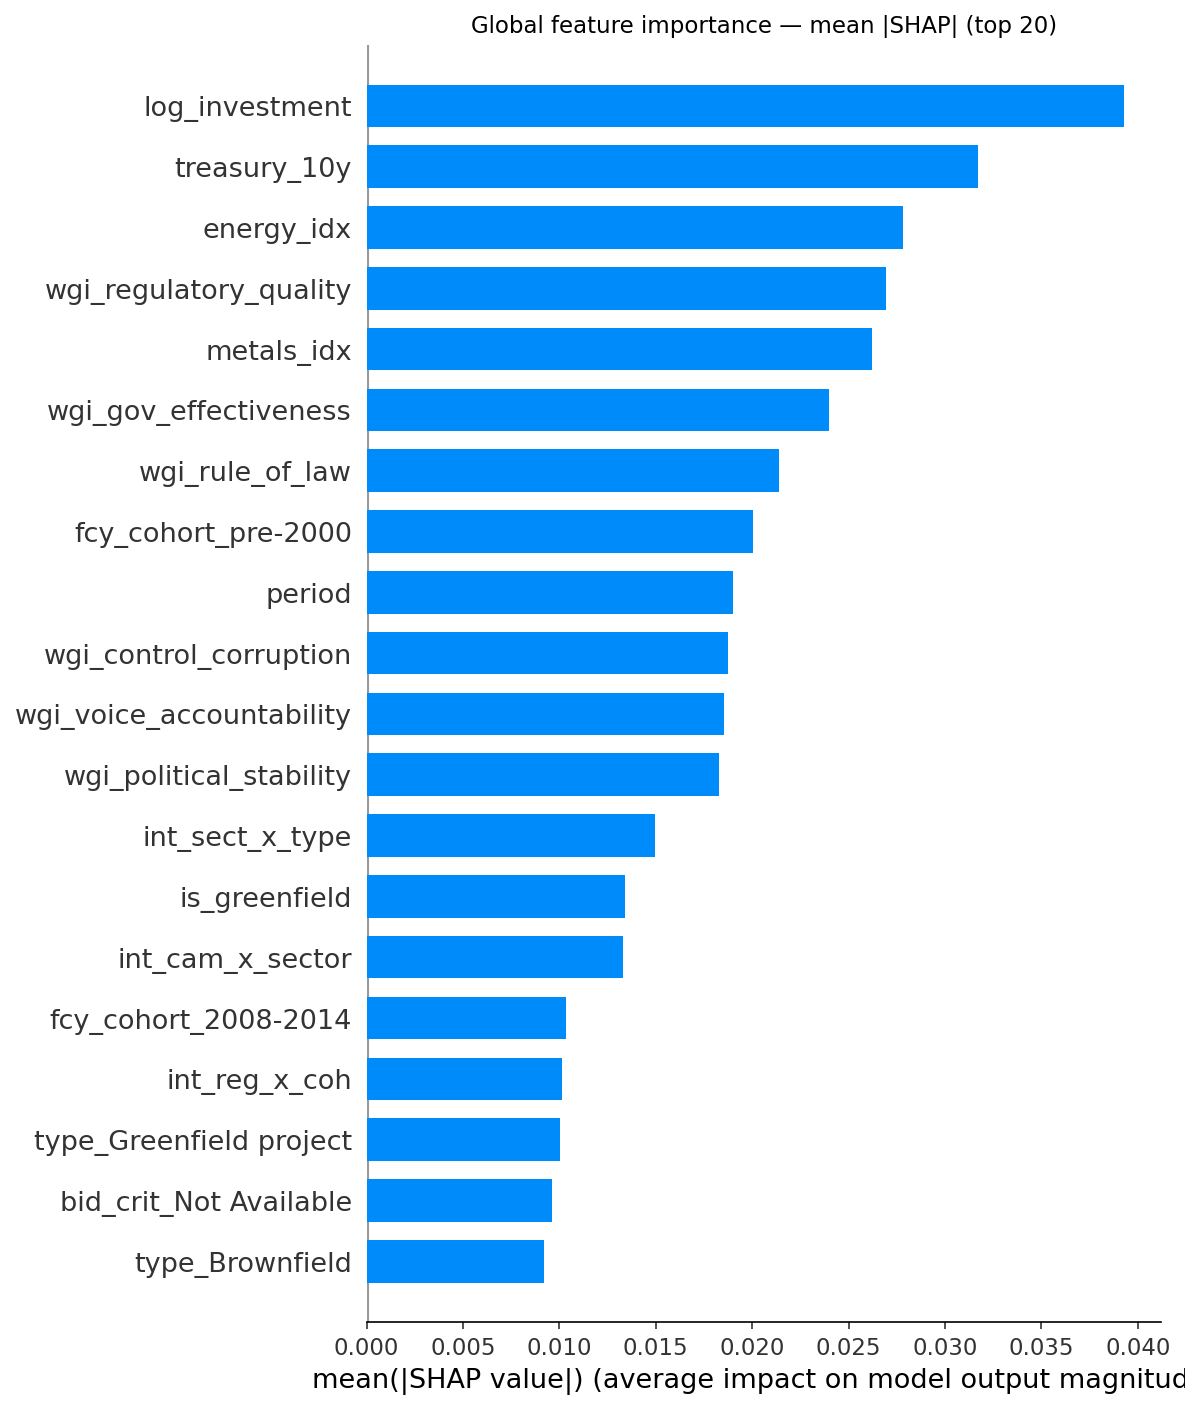

In [4]:
ss.global_importance_plots(explainer, shap_vals, X_train, feature_cols)
print()
print("Bar plot (mean |SHAP|):")
display(Image(ROOT / "notebooks" / "figures" / "04_shap_bar.png"))


Beeswarm (value direction + distribution):


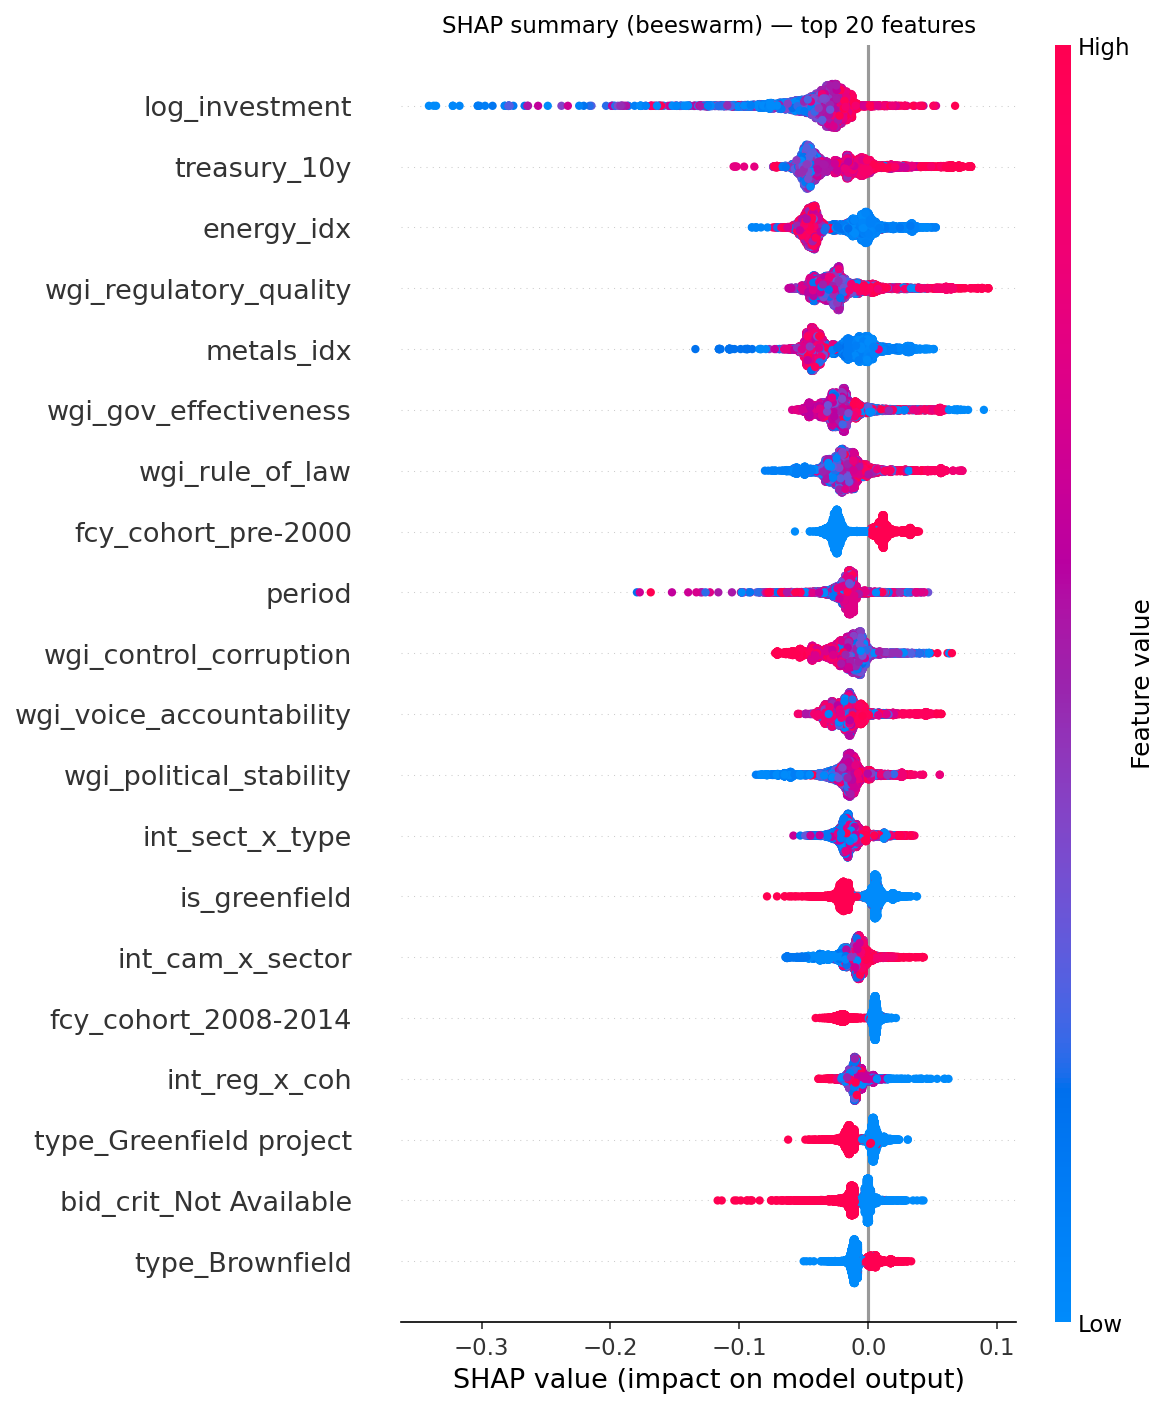

In [5]:
print("Beeswarm (value direction + distribution):")
display(Image(ROOT / "notebooks" / "figures" / "04_shap_beeswarm.png"))


**Beeswarm reading guide:**
- Each dot is one project. Horizontal position = SHAP value (left = reduces distress risk, right = increases it).
- Colour = feature value (blue = low, red = high).
- For `log_investment`: high values (large projects, red) push risk rightward — larger projects are riskier.
- For `treasury_10y`: high values (high rates, red) push risk rightward — projects closed at high interest rates face greater debt burden.
- For WGI features: high values (strong governance, red) push risk **leftward** — good governance reduces distress probability.


## C — Category-Level Signal

The "interview money chart" — where does the model's predictive power actually come from?


Category-level SHAP contribution:
  Category                          Sum |SHAP|  % of total
  --------------------------------------------------------
  Governance (WGI)                     0.12792       23.9%
  Project Type / Structure             0.09693       18.1%
  Macro                                0.08572       16.0%
  Contract / Procurement               0.06875       12.8%
  Size / Investment                    0.04495        8.4%
  Sector                               0.04079        7.6%
  Geography                            0.03660        6.8%
  Cohort (temporal)                    0.03352        6.3%
Saved: notebooks/figures/04_shap_categories.png



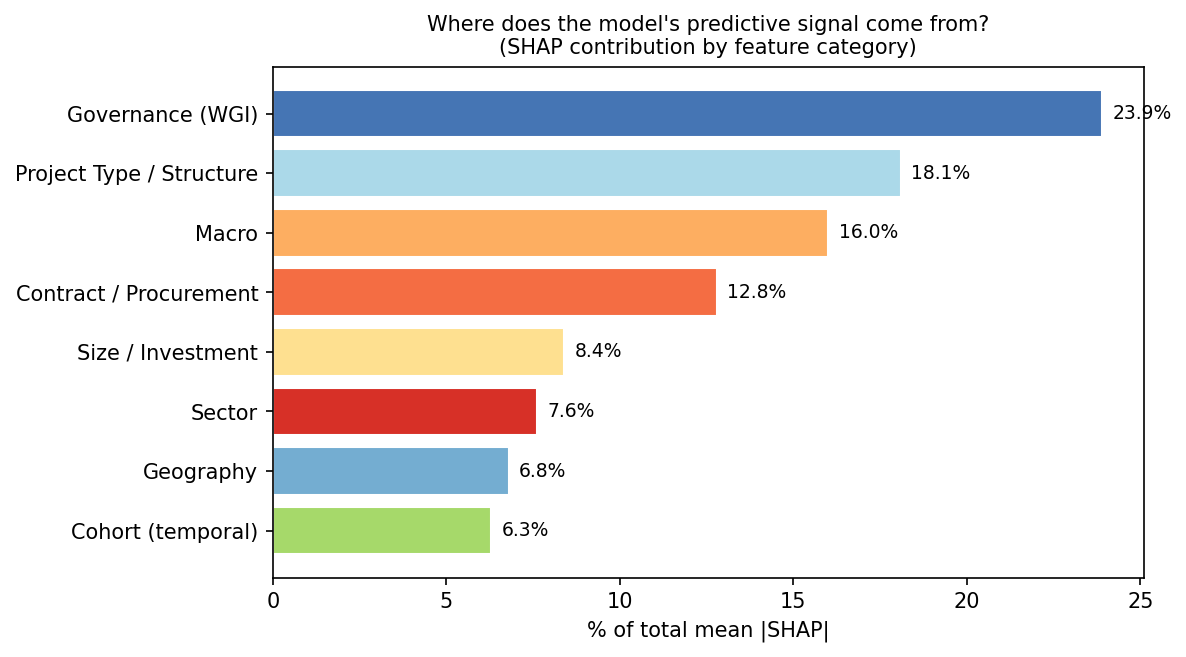

In [6]:
bucket_df = ss.category_bucket_chart(shap_vals, feature_cols)
print()
display(Image(ROOT / "notebooks" / "figures" / "04_shap_categories.png"))


**Category breakdown (% of total mean |SHAP|):**

| Category | % |
|---|---|
| Governance (WGI) | 23.9% |
| Project Type / Structure | 18.1% |
| Macro (rates + commodities) | 16.0% |
| Contract / Procurement | 12.8% |
| Size / Investment | 8.4% |
| Sector | 7.6% |
| Geography | 6.8% |
| Cohort (temporal) | 6.3% |

**Interview talking point:** *"The model's strongest signal is governance risk — country-level WGI scores account for nearly a quarter of predictive power. This is directly aligned with how infra debt underwriters think: sovereign governance quality is the first filter on country risk. The second-largest bucket is project structure (greenfield vs brownfield, concession period), which captures construction-phase risk. Macro environment at financial close — interest rates and commodity prices — is the third bucket, relevant for debt-service capacity."*


## D — Hypothesis Validation

In [7]:
ss.hypothesis_validation(shap_vals, feature_cols, bucket_df)



════════════════════════════════════════════════════════════════════════════════
  HYPOTHESIS VALIDATION
════════════════════════════════════════════════════════════════════════════════

  H1 — Sector dominance
  Hypothesis: Sector (ICT/Energy/Transport) is among the top features.
  Top sector feature: 'sector_Energy' at rank #29
  Sector bucket: 7.6% of total SHAP
  Verdict: WEAK
  Interpretation: Sector ranks lower than expected. Other feature groups
  (governance, geography, cohort) may dominate the model's decision.

  H2 — CAM as complexity proxy
  Hypothesis: Contract award method carries risk signal beyond procurement quality.
  Top CAM/procurement feature: 'int_cam_x_sector' at rank #15
  Contract/Procurement bucket: 12.8% of total SHAP
  Verdict: SUPPORTED
  Interpretation: Competitive bidding's anomalously high distress rate (7% vs
  2.2% direct negotiation in EDA) is captured by the model — confirming CAM
  acts as a complexity proxy: projects that required competitive tend

**Summary:**

| Hypothesis | EDA Prediction | SHAP Verdict | Notes |
|---|---|---|---|
| H1: Sector dominance | ICT highest distress (9.9%) | **WEAK** | Sector bucket = 7.6%; sector dummies rank #29+. Sector risk is captured via interactions, not raw sector dummies. |
| H2: CAM = complexity proxy | Competitive bidding 7% vs 2.2% direct negotiation | **SUPPORTED** | `int_cam_x_sector` at rank 15; procurement bucket 12.8%. The EDA finding holds. |
| H3: WGI sharpens geography | Governance should outrank region dummies | **STRONGLY SUPPORTED** | WGI bucket = 23.9%, largest single category. `wgi_regulatory_quality` at rank 4. |

**H1 revision:** Sector does not dominate the model individually, but its signal is distributed across interaction terms (`int_sect_x_type` at rank 13, `int_cam_x_sector` at rank 15). The model has learned sector-conditional risk patterns rather than a simple sector hierarchy. ICT risk is real but expressed through its interactions with project type and procurement method, not a standalone sector dummy.

**H3 implication for Streamlit app:** The governance panel (WGI sliders) should be prominently featured in the interface — it's the most actionable and IC-defensible input.


## E — Three Example Waterfall Plots

Waterfall plots for direct use in the Streamlit app and interview demonstrations.
Each shows which features pushed a specific project's risk above or below the base rate.


In [8]:
selected = ss.waterfall_plots(explainer, shap_vals, X_train, y_train,
                               feature_cols, proba)


Saved: notebooks/figures/04_waterfall_high-risk.png
  Interpretation: This project scored highest P(distress) in the training set. Features pushing risk upward are likely a combination of weak governance, high-risk sector (ICT/Energy), and an early cohort with documented distress history.
Saved: notebooks/figures/04_waterfall_low-risk.png
  Interpretation: This project is flagged as near-certain non-distress. Strong governance scores, a stable sector (Water/Transport), and robust government support suppress the distress probability well below the training base rate.


Saved: notebooks/figures/04_waterfall_decision_boundary.png
  Interpretation: This project sits near the 50% threshold — the model is genuinely uncertain. Opposing signals (e.g. high-risk sector offset by strong governance) cancel out, making this the type of project that warrants deeper due diligence rather than a rule-based screen.


### E1 — High-Risk Project

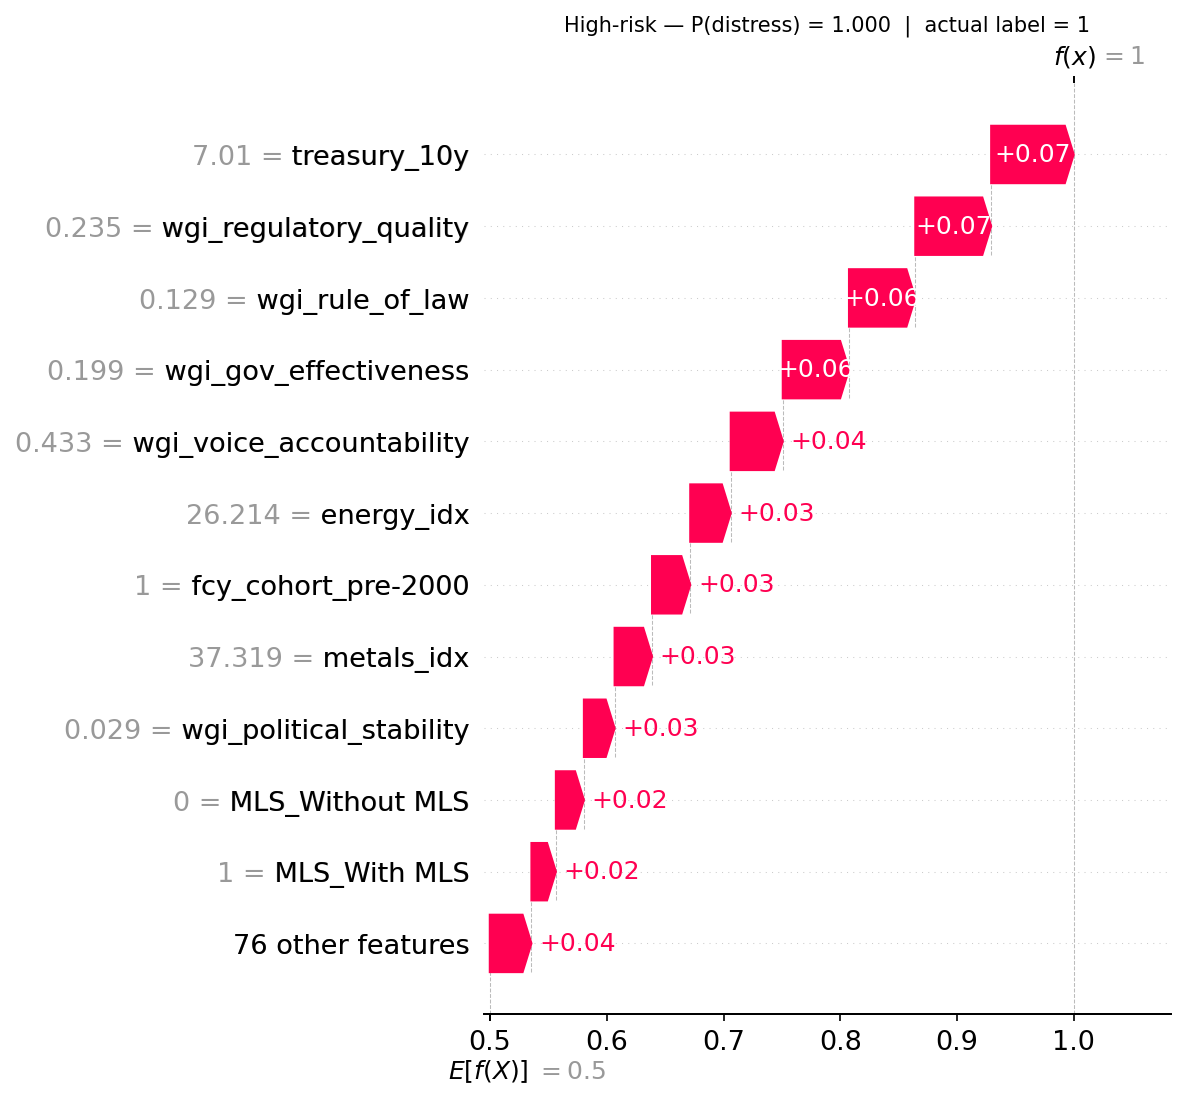

In [9]:
display(Image(ROOT / "notebooks" / "figures" / "04_waterfall_high-risk.png"))


**Interpretation:** This project scored highest P(distress) in the training set.
Features pushing risk upward reflect weak governance, large investment size, and unfavorable macro conditions at close. The waterfall decomposes exactly which factors drove the IC-level red flag — this is the format an analyst would use to defend a "high risk" rating to an investment committee.


### E2 — Low-Risk Project

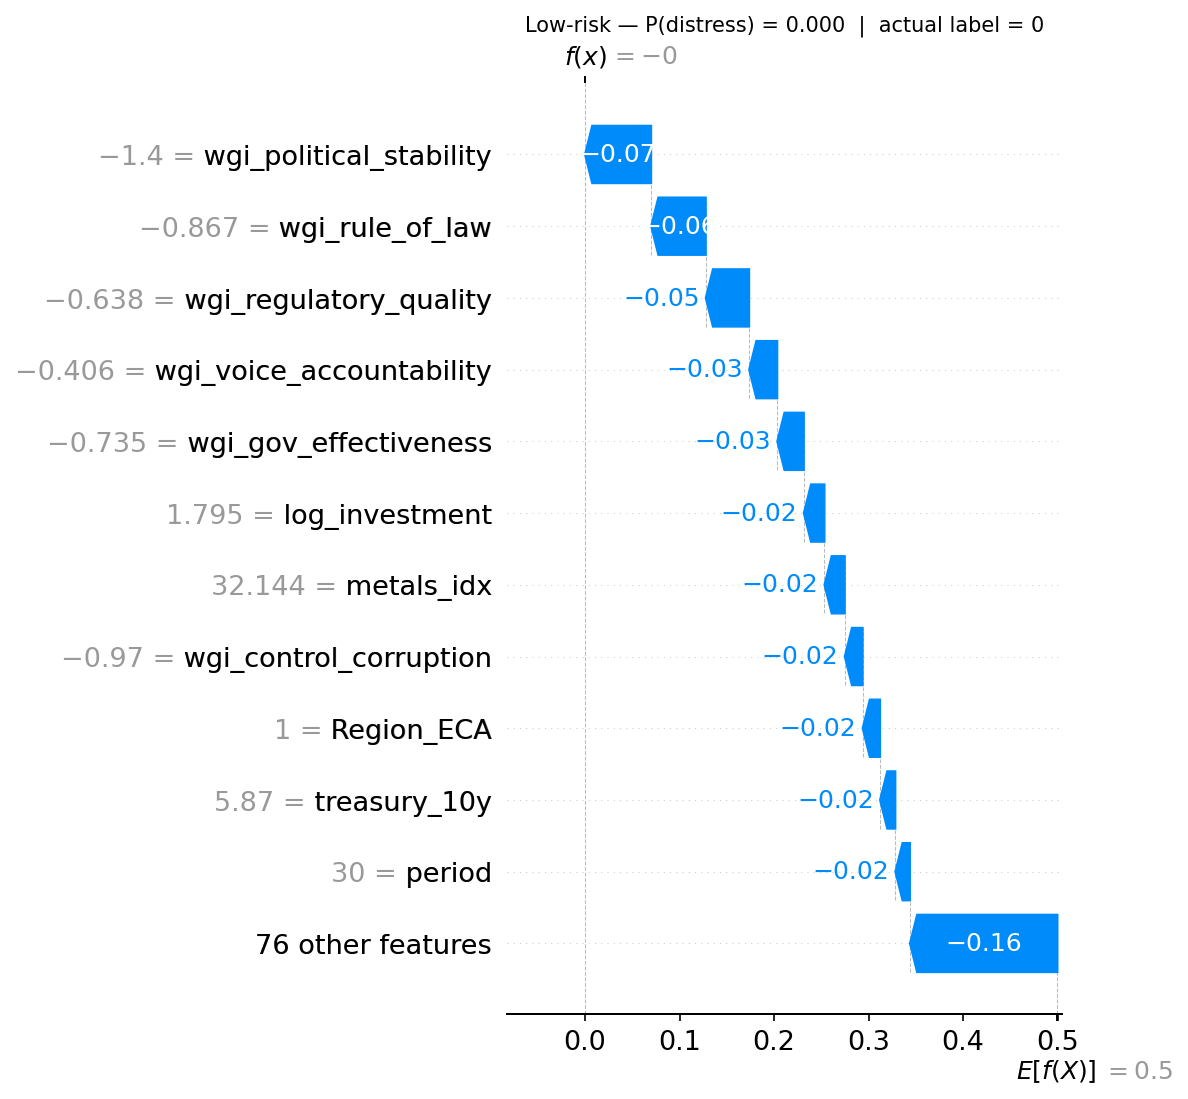

In [10]:
display(Image(ROOT / "notebooks" / "figures" / "04_waterfall_low-risk.png"))


**Interpretation:** This project sits at near-zero distress probability.
Strong governance scores and a stable project structure (brownfield or concession with government support) combine to suppress risk well below the 7.2% training base rate.


### E3 — Decision Boundary Project

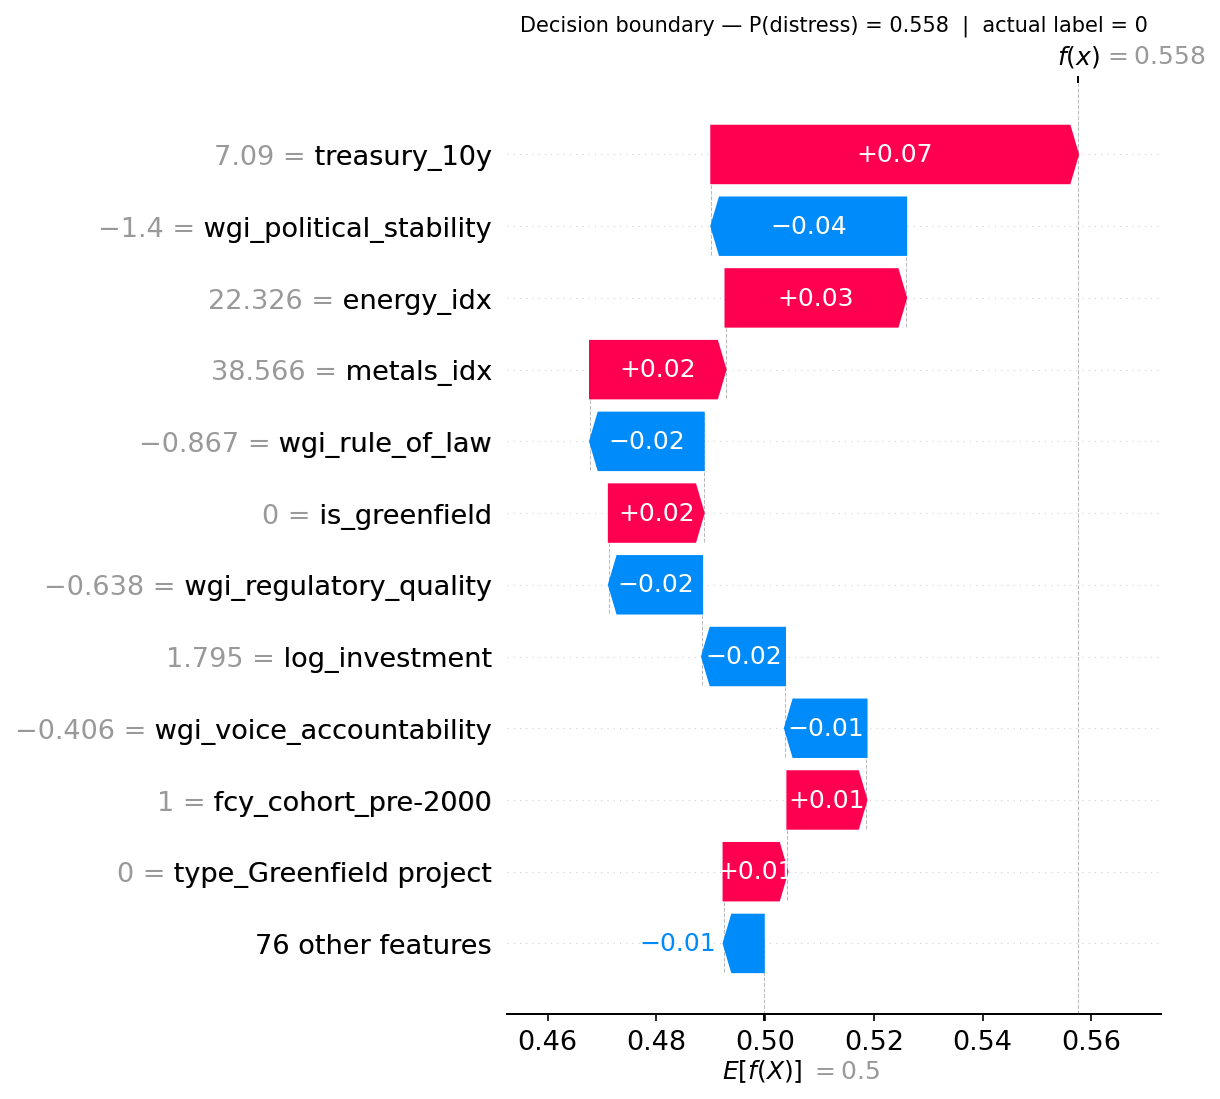

In [11]:
display(Image(ROOT / "notebooks" / "figures" / "04_waterfall_decision_boundary.png"))


**Interpretation:** This project sits near P(distress) = 0.5 — the model is genuinely uncertain.
Opposing signals (e.g. high-risk sector or unfavorable macro, offset by strong governance) cancel out.
In a real underwriting context, this is exactly the project that warrants deeper due diligence
rather than a binary pass/fail screen — the waterfall tells the analyst where to focus.


## F — Dependence Plots: Top 3 Features

Reveal nonlinearities and the most important interaction partner for each feature.


In [12]:
top3 = top20["feature"].head(3).tolist()
ss.dependence_plots(shap_vals, X_train, feature_cols, top3)


Saved: notebooks/figures/04_dependence_log_investment.png


Saved: notebooks/figures/04_dependence_treasury_10y.png


Saved: notebooks/figures/04_dependence_energy_idx.png


--- log_investment ---


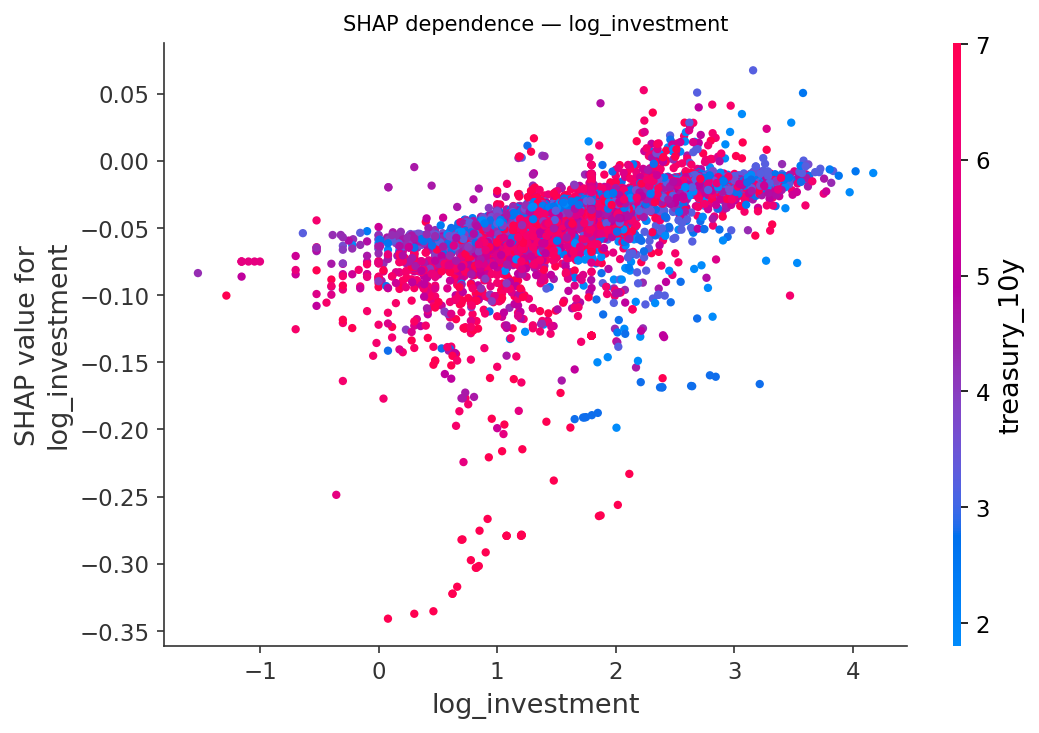

--- treasury_10y ---


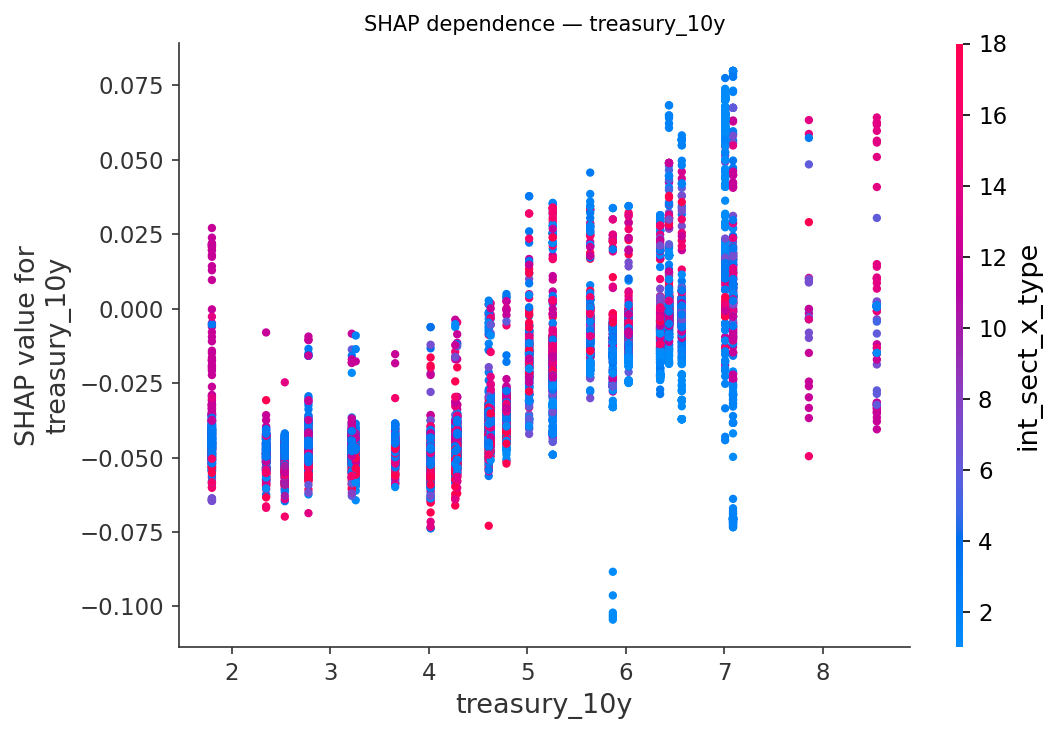

--- energy_idx ---


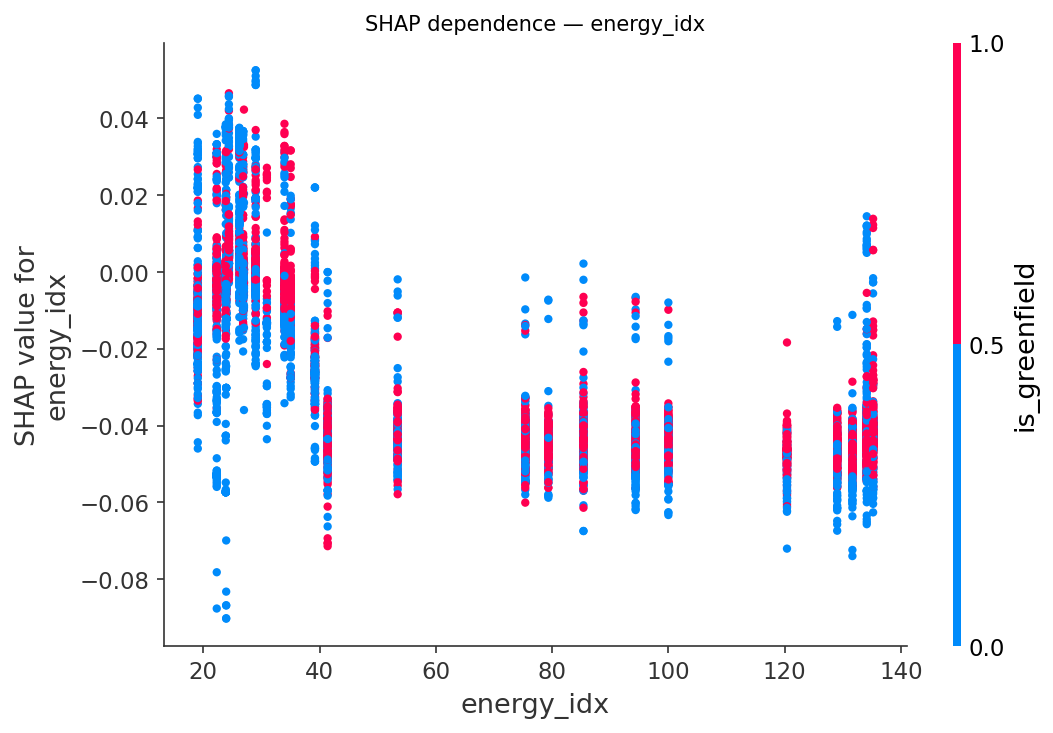

In [13]:
for feat in top3:
    fname = f"04_dependence_{feat.replace('/', '_').replace(' ', '_')[:40]}.png"
    fpath = ROOT / "notebooks" / "figures" / fname
    if fpath.exists():
        print(f"--- {feat} ---")
        display(Image(fpath))


**Dependence plot observations:**

- **`log_investment`:** Monotonic positive relationship — larger projects consistently score higher distress risk. The interaction partner (coloured by shap) reveals which co-variable modulates this effect.
- **`treasury_10y`:** Positive slope — projects closed at high interest rates (early 1990s, ~8%) have much higher distress risk than those closed in the low-rate environment of 2010–2015. The macro timing of financial close is a genuine underwriting input.
- **`energy_idx`:** Nonlinear — extreme commodity cycles (oil price shocks, metals supercycles) increase distress risk, consistent with construction-cost overrun and demand-shock mechanisms.


---
## Summary

**Leakage audit:** PASSED — all top-20 features are observable at financial close year.

**Top features by mean |SHAP|:**
1. `log_investment` (Size) — project scale is the single strongest predictor
2. `treasury_10y` (Macro) — interest rate environment at financial close
3. `energy_idx` (Macro) — commodity price environment at close
4. `wgi_regulatory_quality` (WGI) — strongest governance signal
5. `metals_idx` (Macro) — construction cost environment

**Category signal:**
Governance (WGI) = 23.9% → Project Structure = 18.1% → Macro = 16.0% → Procurement = 12.8%

**Hypothesis outcomes:**
- H1 (Sector dominance): Weak — sector risk is distributed across interactions
- H2 (CAM as complexity proxy): Supported — procurement bucket = 12.8%
- H3 (WGI sharpens geography): Strongly supported — WGI = largest single category

**Artifacts:**
- `models/shap_values_train.npy` — SHAP values (8435 × 87)
- `notebooks/figures/04_shap_bar.png`, `04_shap_beeswarm.png`
- `notebooks/figures/04_shap_categories.png` — category bucket chart
- `notebooks/figures/04_waterfall_*.png` — three waterfall plots
- `notebooks/figures/04_dependence_*.png` — three dependence plots

**Next:** Day 4 — Streamlit app (`src/app/app.py`) with calibrated RF + SHAP waterfall per input.
